In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('CarPred.csv')
df.head()

,make,transmission_type,seats_cop,seats_family,seats_large,fuel_cng,fuel_diesel,fuel_electric,fuel_lpg,fuel_patrol,seller_dealer,seller_self,year,km_driven,engine,max_power,model,selling_price
0,hyundai,0,0,0,1,0,0,1,0,0,0,1,2009,42945,2492,287,verna,210447.937555
1,toyota,0,0,0,1,0,0,0,0,1,1,0,2003,176401,3240,88,corolla,272870.715932
2,ford,1,0,0,0,0,0,0,0,1,1,1,2018,46852,3250,169,aspire,251387.190744
3,honda,1,0,0,0,0,1,0,0,0,1,1,2014,162580,1317,99,jazz,139196.325731
4,hyundai,1,0,0,1,0,1,0,0,0,1,1,2004,11264,3268,196,i10,227022.794299


In [3]:
df.shape

(20000, 18)

Text(0, 0.5, 'Selling Price')

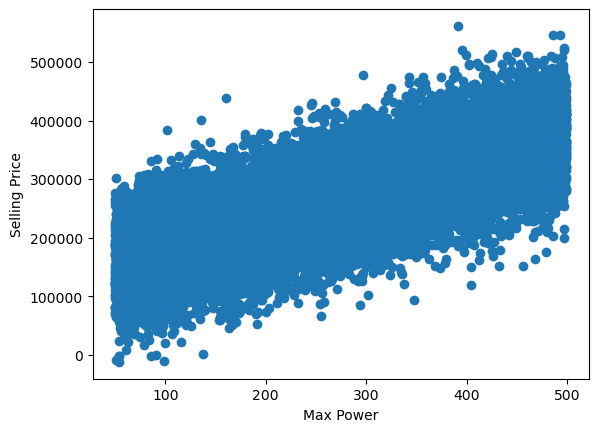

In [4]:
#define x and y
x = df["max_power"].values
y = df["selling_price"].values

plt.scatter(x, y)
plt.xlabel("Max Power")
plt.ylabel("Selling Price")

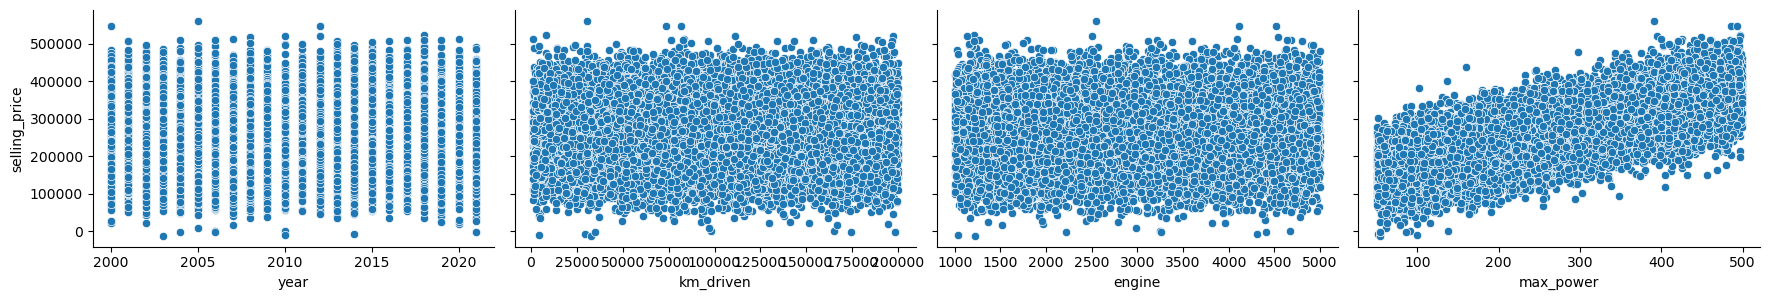

In [28]:
sns.pairplot(df, x_vars=['year', 'km_driven', 'engine', 'max_power'], y_vars='selling_price', height=3, aspect=1.5)

<Axes: >

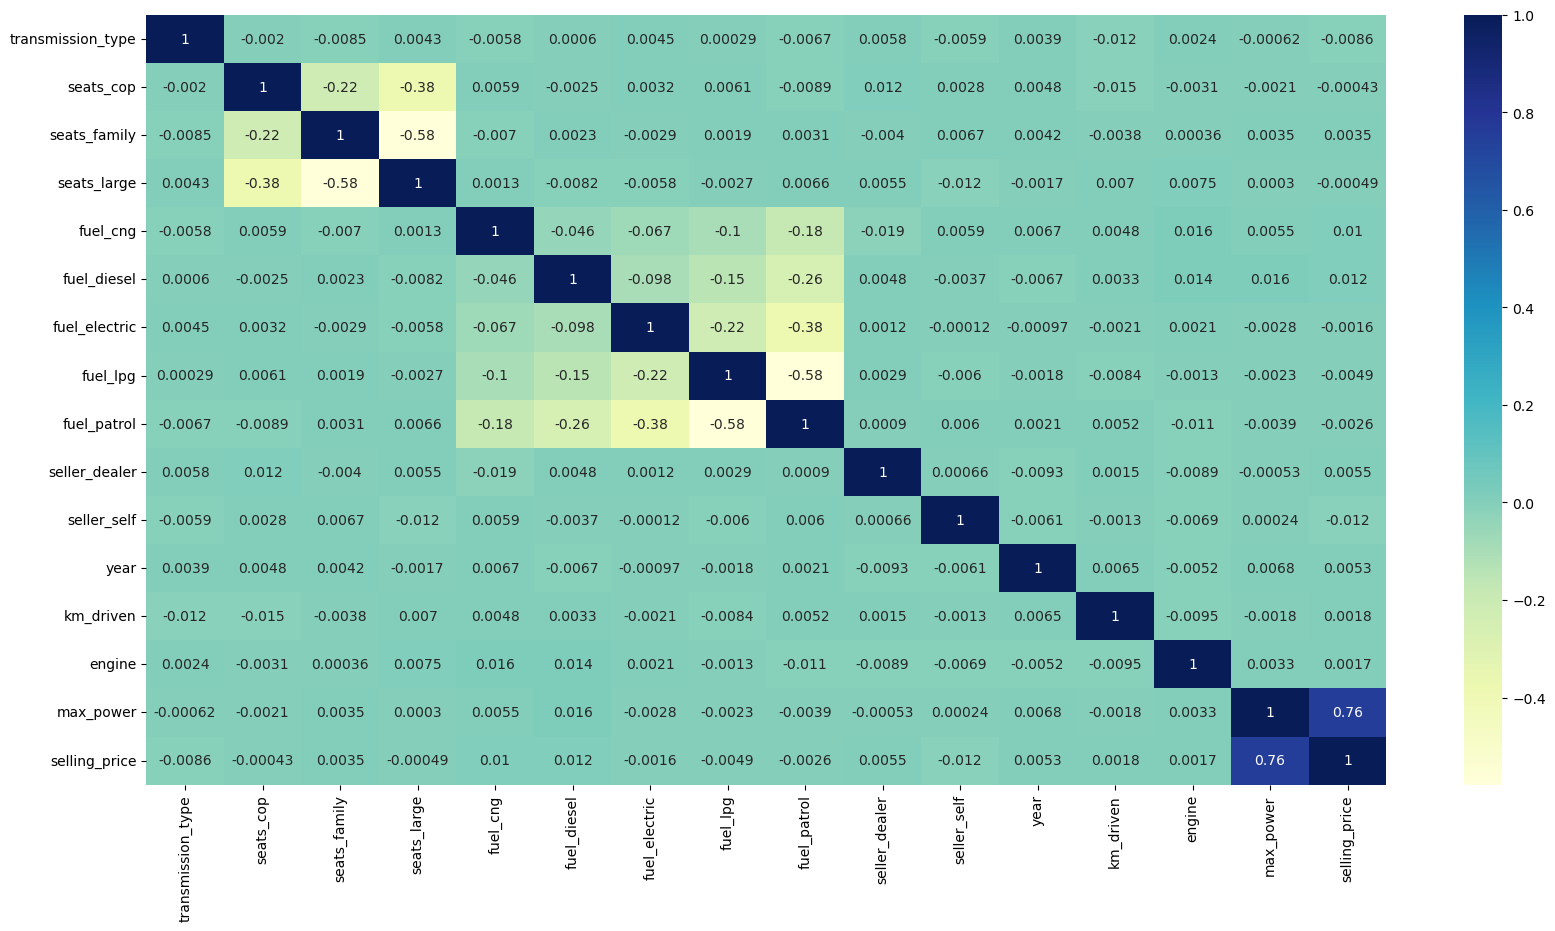

In [35]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='YlGnBu', annot=True, )

In [5]:
# Fit linear regression model
X = df[['year', 'km_driven', 'engine', 'max_power', 'transmission_type', 'seats_cop', 'seats_family', 'seats_large', 'fuel_cng', 'fuel_diesel', 'fuel_electric', 'fuel_patrol', 'fuel_lpg', 'fuel_electric', 'seller_dealer', 'seller_self']]
y = df['selling_price']

In [6]:
import statsmodels.api as sm
# Add a constant term for intercept
X_with_const = sm.add_constant(X)

In [7]:
model = sm.OLS(y, X_with_const).fit()

Text(0.5, 1.0, 'Linearity: Actual vs. Predicted')

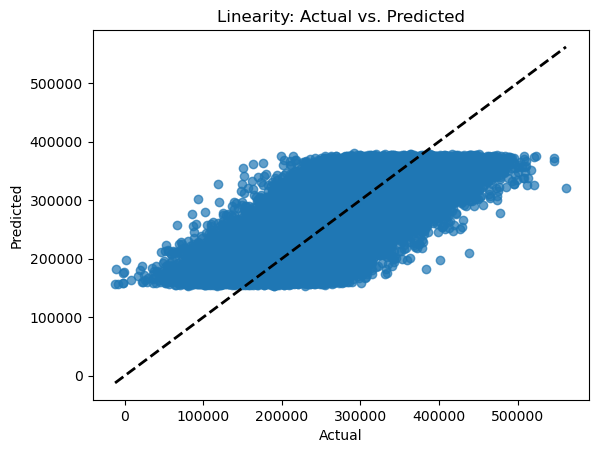

In [9]:
# Check linearity assumption by plotting actual vs. predicted values
plt.scatter(y, model.predict(), alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linearity: Actual vs. Predicted')

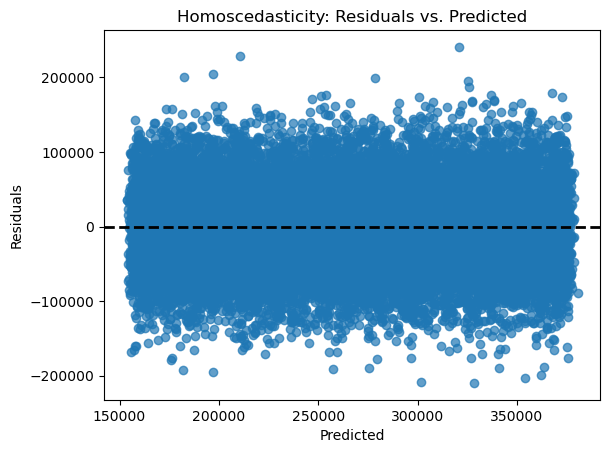

In [10]:
# Check homoscedasticity by plotting residuals vs. predicted values
residuals = model.resid

plt.scatter(model.predict(), residuals, alpha=0.7)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Homoscedasticity: Residuals vs. Predicted')
plt.axhline(y=0, color='k', linestyle='--', lw=2)

Text(0.5, 1.0, 'Normality of Errors: Residuals Histogram')

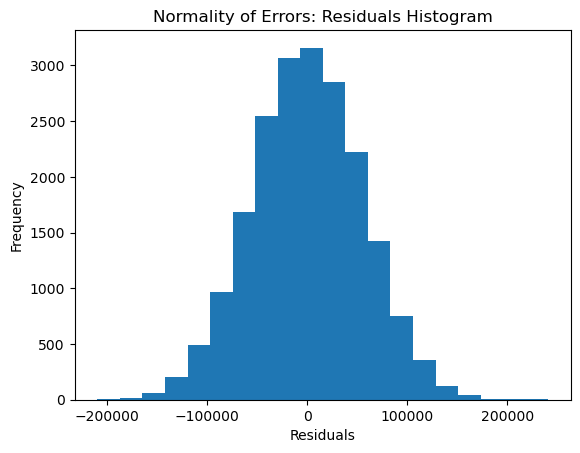

In [11]:
# Check normality of errors by plotting a histogram of residuals
plt.hist(residuals, bins=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Normality of Errors: Residuals Histogram')